
--- Phân tích ETTh2 ---
Shape: (17420, 8)
Bắt đầu tính MI cho 7 biến...
Đã tính xong 7/7 biến. Thời gian: 1.1s
Mean MI: 0.480
Std MI:  0.267
Median MI: 0.381
75% Threshold: 0.504

--- Phân tích Traffic ---
Shape: (17544, 863)
Traffic có 862 cột. Lấy mẫu ngẫu nhiên 100 cột để ước lượng MI...
Bắt đầu tính MI cho 100 biến...
Đã tính xong 50/100 biến. Thời gian: 254.2s
Đã tính xong 100/100 biến. Thời gian: 477.8s
Mean MI: 0.869
Std MI:  0.233
Median MI: 0.841
75% Threshold: 0.993

Đã lưu biểu đồ sắc nét vào file 'mi_histogram_high_res.png' và 'mi_histogram_high_res.pdf'


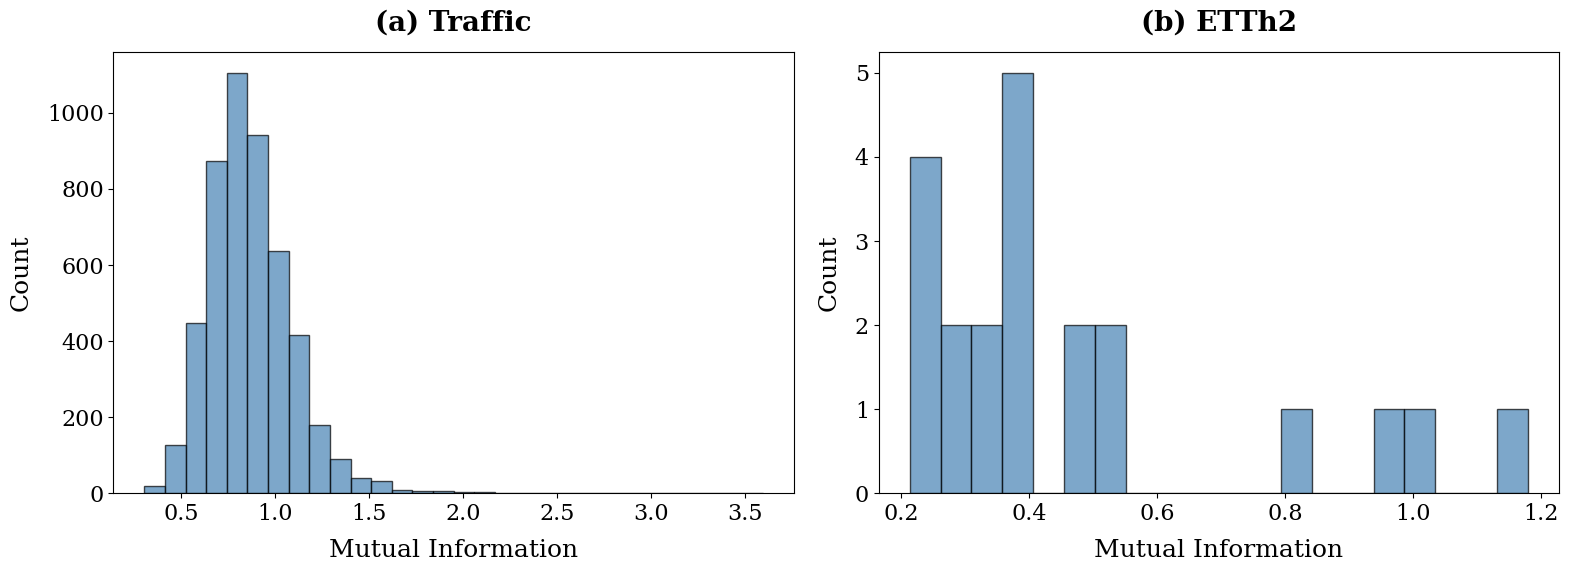

In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import warnings
import time

warnings.filterwarnings('ignore')

def calculate_mi_matrix(df, sample_rows=20000):
    # Lấy các cột số, bỏ cột date nếu có
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Lấy mẫu để tính cho nhanh nếu dữ liệu quá lớn
    if len(numeric_df) > sample_rows:
        numeric_df = numeric_df.sample(sample_rows, random_state=42)
        
    n_features = numeric_df.shape[1]
    mi_matrix = np.zeros((n_features, n_features))
    
    print(f"Bắt đầu tính MI cho {n_features} biến...")
    start_time = time.time()
    
    # Tính MI giữa từng cặp biến
    for i in range(n_features):
        y = numeric_df.iloc[:, i].values
        X = numeric_df.values
        mi = mutual_info_regression(X, y, random_state=42)
        mi_matrix[i, :] = mi
        
        if (i+1) % 50 == 0 or i == n_features - 1:
            print(f"Đã tính xong {i+1}/{n_features} biến. Thời gian: {time.time()-start_time:.1f}s")
            
    return mi_matrix

def analyze_dataset(file_path, dataset_name):
    print(f"\n--- Phân tích {dataset_name} ---")
    try:
        df = pd.read_csv(file_path)
        print(f"Shape: {df.shape}")
        
        numeric_df = df.select_dtypes(include=[np.number])
        # Nếu dataset quá lớn (như traffic 862 cột), lấy mẫu 100 cột ngẫu nhiên để tính MI nhanh
        if numeric_df.shape[1] > 100:
            print(f"{dataset_name} có {numeric_df.shape[1]} cột. Lấy mẫu ngẫu nhiên 100 cột để ước lượng MI...")
            numeric_df = numeric_df.sample(n=100, axis=1, random_state=42)
            
        mi_matrix = calculate_mi_matrix(numeric_df, sample_rows=5000)
        
        # Lấy giá trị nửa trên đường chéo (tránh trùng lặp và đường chéo chính)
        n = mi_matrix.shape[0]
        mi_values = mi_matrix[np.triu_indices(n, k=1)]
        
        mean_mi = np.mean(mi_values)
        std_mi = np.std(mi_values)
        median_mi = np.median(mi_values)
        p75_mi = np.percentile(mi_values, 75)
        
        print(f"Mean MI: {mean_mi:.3f}")
        print(f"Std MI:  {std_mi:.3f}")
        print(f"Median MI: {median_mi:.3f}")
        print(f"75% Threshold: {p75_mi:.3f}")
        
        return mi_values, {'Mean MI': mean_mi, 'Std MI': std_mi, 'Median MI': median_mi, '75% Threshold': p75_mi}
    except Exception as e:
        print(f"Lỗi khi đọc hoặc xử lý {file_path}: {e}")
        return None, None

def main():
    etth2_path = r"data\ETTh2.csv"
    traffic_path = r"data\traffic.csv"
    
    etth2_mi, _ = analyze_dataset(etth2_path, "ETTh2")
    traffic_mi, _ = analyze_dataset(traffic_path, "Traffic")
    
    # Plotting (sử dụng matplotlib thay vì seaborn để tránh lỗi thiếu thư viện)
        # Plotting (Đã tối ưu phông chữ cho Overleaf/LaTeX)
    if etth2_mi is not None and traffic_mi is not None:
        # Cài đặt kích thước phông chữ chuẩn cho bài báo
        plt.rcParams.update({
            # 'font.family': 'serif', # Dùng font có chân cho giống chuẩn LaTeX
            'font.size': 16,
            'axes.titlesize': 20,   # Tiêu đề biểu đồ to rõ
            'axes.labelsize': 18,   # Nhãn trục X, Y to
            'xtick.labelsize': 16,  # Số trên trục X
            'ytick.labelsize': 16   # Số trên trục Y
        })
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Phóng to khung hình một chút
        
        # Biểu đồ (a) Traffic
        axes[0].hist(traffic_mi, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[0].set_title('(a) Traffic', pad=15, fontweight='bold')
        axes[0].set_xlabel('Mutual Information', labelpad=10)
        axes[0].set_ylabel('Count', labelpad=10)
        
        # Biểu đồ (b) ETTh2
        axes[1].hist(etth2_mi, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[1].set_title('(b) ETTh2', pad=15, fontweight='bold')
        axes[1].set_xlabel('Mutual Information', labelpad=10)
        axes[1].set_ylabel('Count', labelpad=10)
        
        plt.tight_layout()
        
        # Lưu với chuẩn dpi=300 cực nét cho bài báo Q1, thêm bbox_inches='tight' để không bị cắt lề
        plt.savefig('mi_histogram_high_res.png', dpi=300, bbox_inches='tight')
        plt.savefig('mi_histogram_high_res.pdf', bbox_inches='tight') # Khuyên dùng định dạng .pdf cho Overleaf
        print("\nĐã lưu biểu đồ sắc nét vào file 'mi_histogram_high_res.png' và 'mi_histogram_high_res.pdf'")
        
if __name__ == "__main__":
    main()
